In [9]:
import os
import re
import numpy as np
import cv2
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from scipy.fft import rfft, rfftfreq
from scipy.ndimage import shift as nd_shift
from skimage.registration import phase_cross_correlation
from filterpy.kalman import KalmanFilter
from filterpy.common import Q_discrete_white_noise

import warnings
warnings.filterwarnings("ignore")

In [10]:
# Configuration
DATASET_DIR = r"C:\Users\valekseeva\Documents\GitHub\DiffScale\DiffScale-main\data\distorted"
PIXEL_SIZE_UM = 7.0
IMAGE_WIDTH = 800
IMAGE_HEIGHT = 4
PATTERN_PERIOD_PX = 80 

NUM_FRAMES = 20 

print("Configuration loaded.")
print(f"Physical period: {PATTERN_PERIOD_PX * PIXEL_SIZE_UM} µm")

Configuration loaded.
Physical period: 560.0 µm


In [11]:
# Функция загрузки данных
def load_dataset(dataset_dir, NUM_FRAMES=30):
    """
    Load and organize the dataset from the given directory.
    Returns a 3D numpy array of shape (num_distortions, frames_per_distortion, height, width).
    """
    file_groups = {}
    
    for f in os.listdir(dataset_dir):
        if not f.endswith('.png'):
            continue
        
        # Extract distortion type and frame ID from filename
        base = f.replace('.png', '')
        if '_' in base:
            _, rest = base.split('_', 1)
            distortion_type = re.split(r'_frame_\d+$', rest)[0]
        else:
            distortion_type = base 

        frame_match = re.search(r'_frame_(\d+)$', base)
        if not frame_match:
            continue
        frame_id = int(frame_match.group(1))

        if distortion_type not in file_groups:
            file_groups[distortion_type] = []
        file_groups[distortion_type].append((frame_id, f))
    
    # Filter and sort groups
    valid_groups = {}
    for dtype, files in file_groups.items():
        if len(files) == NUM_FRAMES: 
            files_sorted = sorted(files, key=lambda x: x[0])
            valid_groups[dtype] = [fname for _, fname in files_sorted]

    print(f"Found {len(valid_groups)} valid distortion groups with 20 frames each.")
    
    # Create the dataset array
    distortion_types = sorted(valid_groups.keys())
    dataset = np.zeros((len(valid_groups), NUM_FRAMES, IMAGE_HEIGHT, IMAGE_WIDTH), dtype=np.float32)

    for d_idx, dtype in enumerate(distortion_types):
        for f_idx, filename in enumerate(valid_groups[dtype]):
            path = os.path.join(dataset_dir, filename)
            img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
            if img is None:
                raise IOError(f"Failed to load image: {path}")
            if img.shape != (IMAGE_HEIGHT, IMAGE_WIDTH):
                raise ValueError(f"Unexpected image shape {img.shape} in {path}")
            dataset[d_idx, f_idx] = img.astype(np.float32)
    
    return dataset, distortion_types

In [12]:
# Load the data
dataset, distortion_types = load_dataset(DATASET_DIR, NUM_FRAMES=30)
print(f"Dataset shape: {dataset.shape}")

Found 7 valid distortion groups with 20 frames each.
Dataset shape: (7, 30, 4, 800)


Для задачи субпиксельной обработки изображений размером 800×4 пикселей с целью достижения разрешения в нанометрах (при физическом размере пикселя 7 мкм и периоде структуры 560 мкм) используется подход на основе **фазовой корреляции (Phase Correlation, PC)** с последующей фильтрацией Калмана.

In [13]:
def compute_accumulated_phase_shift(frames, period_px=PATTERN_PERIOD_PX):
    """
    Compute subpixel shifts using accumulated phase with unwrapping.
    Returns array of displacements in pixels.
    """
    N = len(frames)
    phases = []
    target_freq = 1.0 / period_px

    for frame in frames:
        signal_1d = np.mean(frame, axis=0)
        signal_1d = signal_1d - np.mean(signal_1d)  # Remove DC
        
        # FFT to get phase at fundamental frequency
        N_sig = len(signal_1d)
        fft_vals = rfft(signal_1d)
        freqs = rfftfreq(N_sig, d=1.0)
        idx = np.argmin(np.abs(freqs - target_freq))
        phase = -np.angle(fft_vals[idx])  # Инвертируем знак фазы
        phases.append(phase)
    
    phases = np.array(phases)
    unwrapped_phases = np.unwrap(phases)  # Correct jumps > π
    
    # Subtract initial phase to remove bias
    unwrapped_phases = unwrapped_phases - unwrapped_phases[0]
    
    # Convert to displacement in pixels
    displacements_px = unwrapped_phases / (2 * np.pi) * period_px

    print("Phases (rad):", phases[:5])
    print("Unwrapped phases:", unwrapped_phases[:5])
    print("Displacements (px):", displacements_px[:5])
    
    # Return differential shifts
    diff_px = np.diff(displacements_px)
    return diff_px

In [14]:
# Algorithm 2: Edge Detection + Subpixel Localization (Gaussian Fit)

# def gaussian(x, a, x0, sigma, offset):
#     return a * np.exp(-(x - x0)**2 / (2 * sigma**2)) + offset

# def locate_edge_subpixel(img, window=30):
#     """
#     Locate an edge with subpixel accuracy by fitting a Gaussian to its gradient.
#     Requires a good initial guess for the edge location.
#     """
#     img_1d = np.mean(img, axis=0)
#     img_1d = (img_1d - np.min(img_1d)) / (np.max(img_1d) - np.min(img_1d) + 1e-8)

#     # Бандпасс-фильтр
#     filtered = bandpass_filter(img_1d, LOWCUT, HIGHCUT, fs=1.0)
    
#     grad = np.gradient(filtered)
    
#     # Gradient
#     grad = np.gradient(filtered)
    
#     # Find the first strong boundary in the first period
#     edge_guess = np.argmax(np.abs(grad[:PATTERN_PERIOD_PX]))
    
#     # The window around the intended edge
#     start = max(0, int(edge_guess - window // 2))
#     end = min(len(filtered), int(edge_guess + window // 2))
#     x_crop = np.arange(start, end)
#     grad_crop = grad[start:end]
    
#     if len(grad_crop) < 5:
#         return edge_guess
    
#     try:
#         popt, _ = curve_fit(gaussian, x_crop, grad_crop,
#                            p0=[grad_crop.max(), edge_guess, 2.0, 0.0],
#                            maxfev=1000)
#         return popt[1]  
#     except (RuntimeError, ValueError):
#         return x_crop[np.argmax(grad_crop)]


In [15]:
# Algorithm 3: Normalized Cross-Correlation (NCC)

# def normalized_cross_correlation_shift(prev_img, curr_img):
#     """
#     Estimate the global shift of an image relative to a template using cross-correlation.
#     Includes subpixel refinement via parabolic interpolation.
#     """
#     # Line averaging
#     prev_1d = np.mean(prev_img, axis=0)
#     curr_1d = np.mean(curr_img, axis=0)
    
#     # Normalization
#     prev_1d = (prev_1d - np.mean(prev_1d)) / (np.std(prev_1d) + 1e-8)
#     curr_1d = (curr_1d - np.mean(curr_1d)) / (np.std(curr_1d) + 1e-8)
    
#     # Бандпасс-фильтр
#     prev_filtered = bandpass_filter(prev_1d, LOWCUT, HIGHCUT, fs=1.0)
#     curr_filtered = bandpass_filter(curr_1d, LOWCUT, HIGHCUT, fs=1.0)
    
#     # Calculating the correlation
#     correlation = np.correlate(prev_filtered, curr_filtered, mode='full')
#     lag = np.argmax(correlation) - (len(prev_filtered) - 1)
    
#     # Parabolic interpolation for subpixel refinement
#     if 1 <= lag < len(correlation) - 1:
#         y1, y2, y3 = correlation[lag-1], correlation[lag], correlation[lag+1]
#         if (y1 - 2*y2 + y3) != 0:
#             subpixel_offset = 0.5 * (y1 - y3) / (y1 - 2*y2 + y3)
#             return lag + subpixel_offset
    
#     return float(lag)

In [16]:
# Настройка Kalman Filter

def estimate_measurement_noise_from_static(static_shifts):
    """Estimate R from static measurements."""
    return np.var(static_shifts) if len(static_shifts) > 1 else 1.0

def create_kalman_filter(R_initial=1.0, Q_initial=1.0):
    kf = KalmanFilter(dim_x=2, dim_z=1)
    kf.x = np.array([0., 0.])
    kf.F = np.array([[1., 1.],
                     [0., 1.]])
    kf.H = np.array([[1., 0.]])
    kf.P *= 1000.
    kf.R = R_initial
    kf.Q = np.eye(2) * Q_initial
    return kf

def estimate_R_Q_for_type(diff_nm, full_frames):
    """
    Estimate R (measurement noise) and Q (process noise) from data.
    """
    # Estimate R: process first frame multiple times
    static_frames = full_frames[:10]  # shape (10, 4, 800)
    diff_px_list_static = compute_accumulated_phase_shift(static_frames, PATTERN_PERIOD_PX)
    diff_nm_static = diff_px_list_static * PIXEL_SIZE_UM * 1000

    R_est = np.var(diff_nm_static) if len(diff_nm_static) > 1 else 1.0
    if R_est == 0.0:
        R_est = 1.0  
    
    # Q_est: variance of acceleration (difference of differences)
    if len(diff_nm) >= 3:
        acceleration = np.diff(diff_nm)
        Q_est = np.var(acceleration)
    else:
        Q_est = 1e-3  
    
    return R_est, Q_est

In [17]:
# Обработка всех типов искажений

results_all = {}

for d_idx, dtype in enumerate(distortion_types):
    full_frames = dataset[d_idx]  # shape (30, 4, 800)
    analysis_frames = full_frames[10:30]   # shape (20, 4, 800)
    diff_px_list = compute_accumulated_phase_shift(analysis_frames, PATTERN_PERIOD_PX)
    diff_nm = diff_px_list * PIXEL_SIZE_UM * 1000

    cumulative_raw = np.concatenate([[0.0], np.cumsum(diff_nm)])

    # Estimate R and Q
    R_est, Q_est = estimate_R_Q_for_type(diff_nm, full_frames)

    # Применяем Kalman Filter к накопленному смещению
    kf = create_kalman_filter(R_initial=R_est, Q_initial=Q_est)
    cumulative_kalman = []
    for z in cumulative_raw:
        kf.predict()
        kf.update(z)
        cumulative_kalman.append(kf.x[0])
    cumulative_kalman = np.array(cumulative_kalman)
    diff_kalman = np.diff(cumulative_kalman)
    
    results_all[dtype] = {
        'diff_raw': diff_nm,
        'cumulative_raw': cumulative_raw,
        'cumulative_kalman': cumulative_kalman,
        'diff_kalman': diff_kalman,
        'R_est': R_est,
        'Q_est': Q_est
    }

Phases (rad): [1.7671459 1.8083738 1.8456857 1.8869137 1.9242254]
Unwrapped phases: [0.         0.04122794 0.07853985 0.11976779 0.15707958]
Displacements (px): [0.        0.5249304 1.0000004 1.5249307 1.9999993]
Phases (rad): [1.7671459 1.7671459 1.7671459 1.7671459 1.7671459]
Unwrapped phases: [0. 0. 0. 0. 0.]
Displacements (px): [0. 0. 0. 0. 0.]
Phases (rad): [1.7698705 1.8113549 1.8468313 1.900723  1.9191152]
Unwrapped phases: [0.         0.04148436 0.0769608  0.13085246 0.14924467]
Displacements (px): [0.         0.5281952  0.97989535 1.6660652  1.9002421 ]
Phases (rad): [1.7686737 1.7733663 1.7750075 1.7734017 1.7660958]
Unwrapped phases: [ 0.          0.00469267  0.00633383  0.00472808 -0.0025779 ]
Displacements (px): [ 0.          0.05974898  0.08064479  0.06019977 -0.03282285]
Phases (rad): [1.7726468 1.8137758 1.8511939 1.8923081 1.9297571]
Unwrapped phases: [0.         0.04112899 0.07854712 0.11966133 0.15711033]
Displacements (px): [0.         0.52367055 1.000093   1.523575

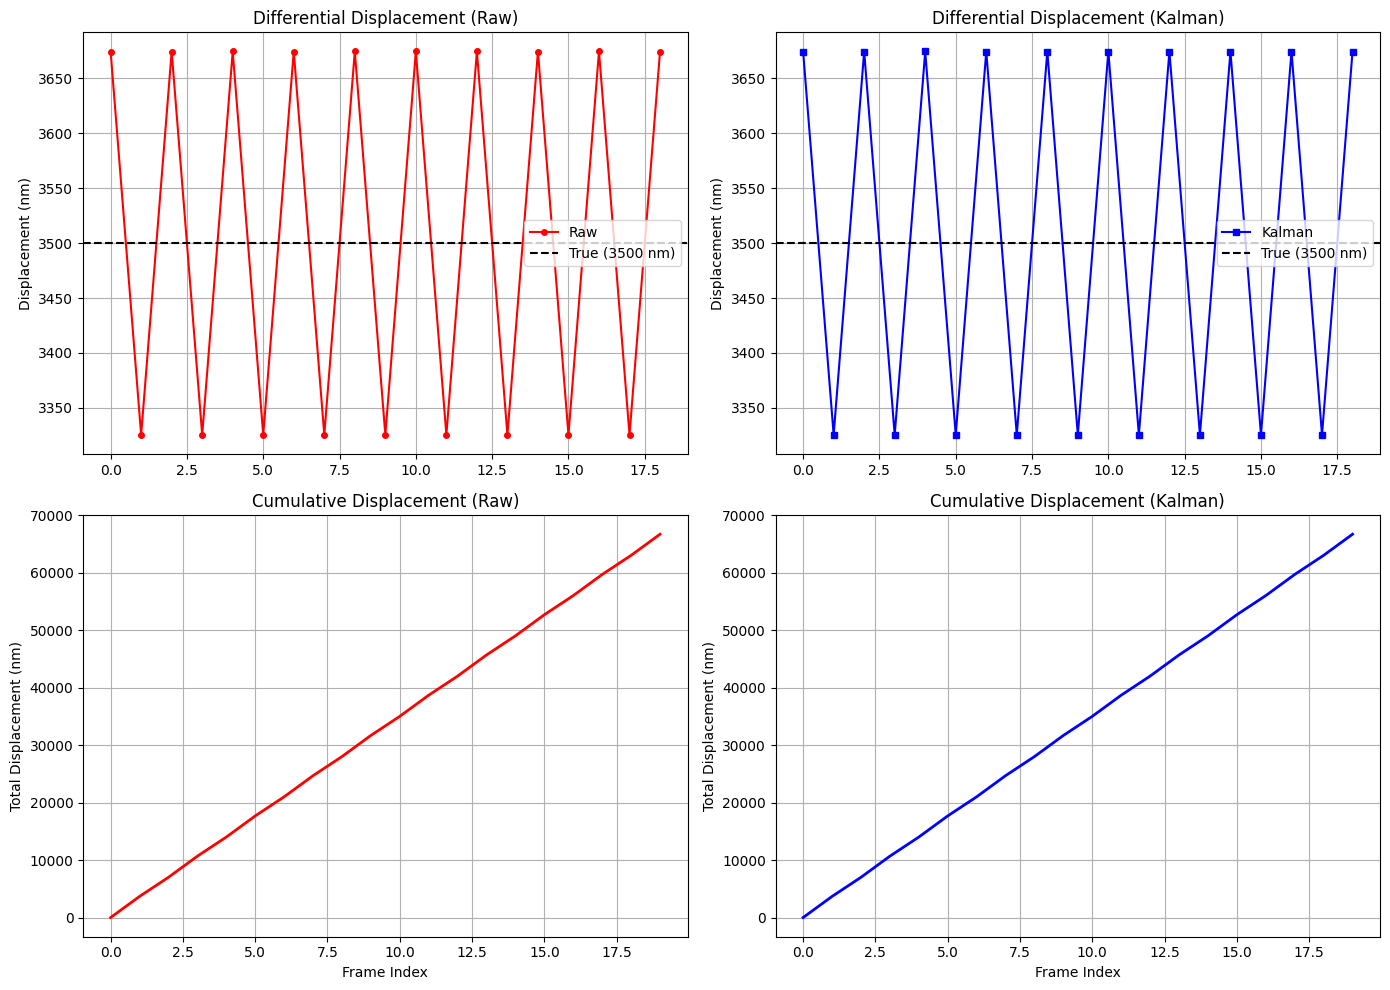

Stats for blur:
  Distortion Type: blur
  Raw Accuracy Std (nm): 174.273681640625
  Kalman Accuracy Std (nm): 174.27
  Improvement (%): 0.00
  Final Raw Disp (nm): 66674.50
  Final Kalman Disp (nm): 66674.50
  R_est (nm^(2)): 1.00
  Q_est (nm^(2)/frame^(2)): 121823.265625


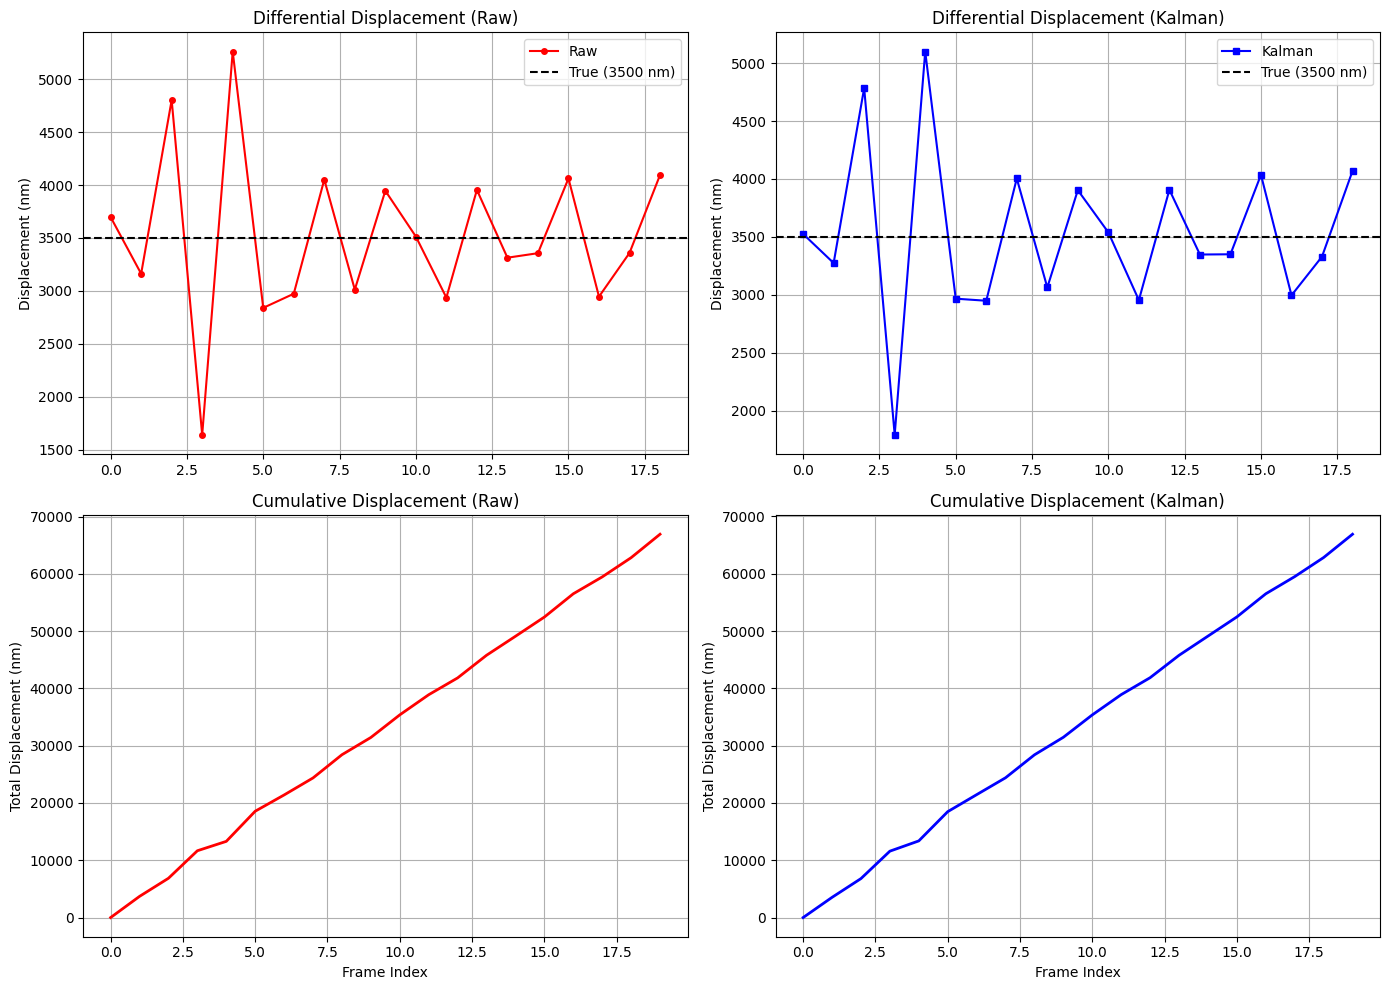

Stats for combined:
  Distortion Type: combined
  Raw Accuracy Std (nm): 776.1224975585938
  Kalman Accuracy Std (nm): 717.25
  Improvement (%): 7.59
  Final Raw Disp (nm): 66920.47
  Final Kalman Disp (nm): 66894.02
  R_est (nm^(2)): 224426.96875
  Q_est (nm^(2)/frame^(2)): 2197025.0


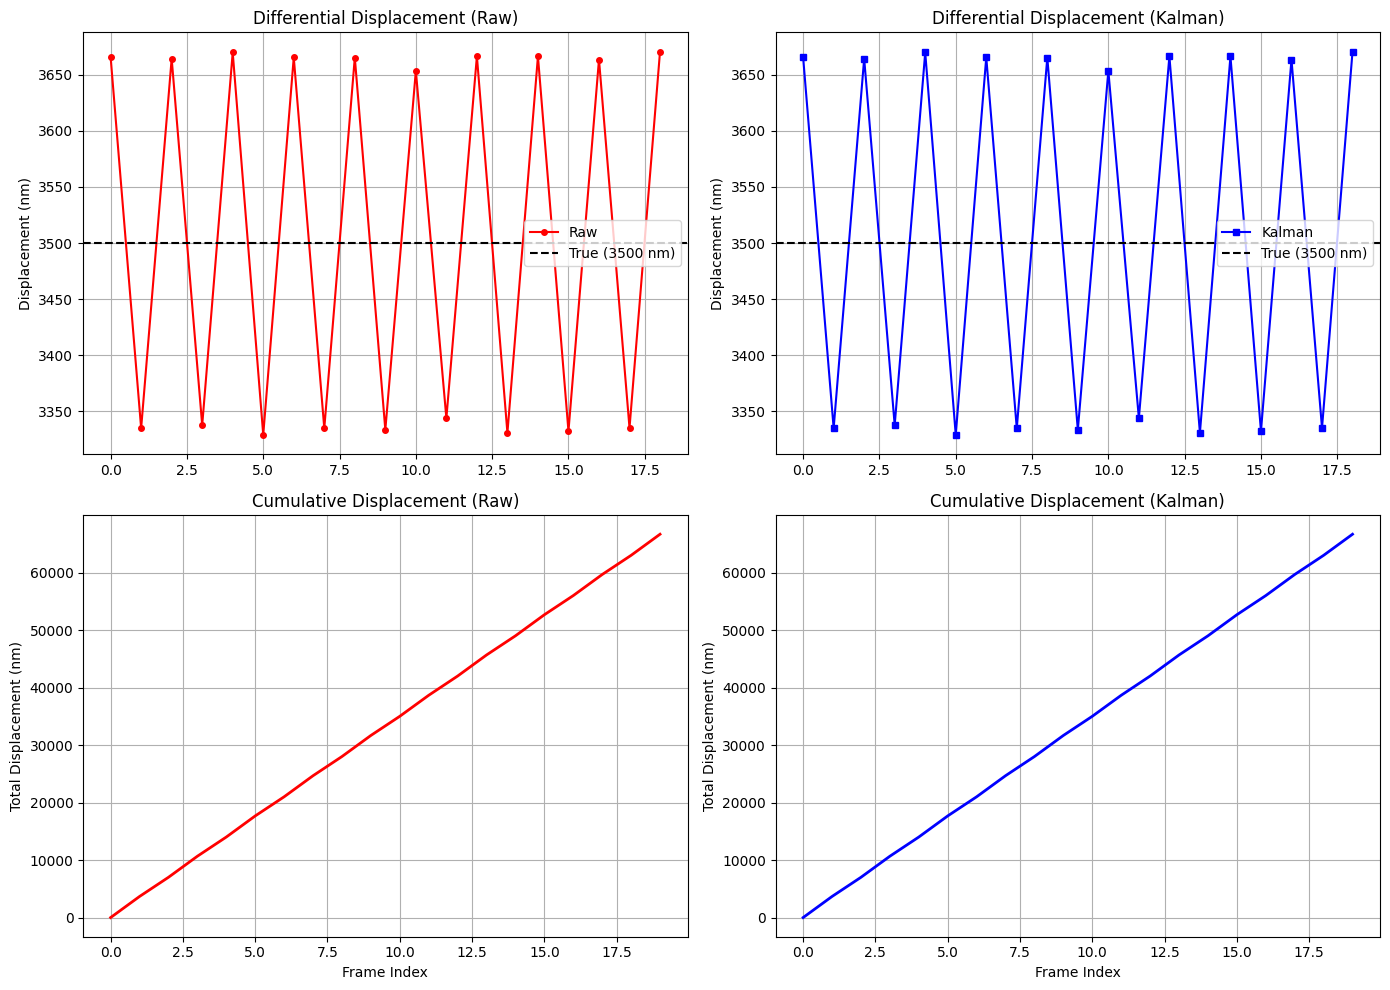

Stats for lighting:
  Distortion Type: lighting
  Raw Accuracy Std (nm): 165.03941345214844
  Kalman Accuracy Std (nm): 165.04
  Improvement (%): 0.00
  Final Raw Disp (nm): 66664.34
  Final Kalman Disp (nm): 66664.34
  R_est (nm^(2)): 1.00
  Q_est (nm^(2)/frame^(2)): 109006.375


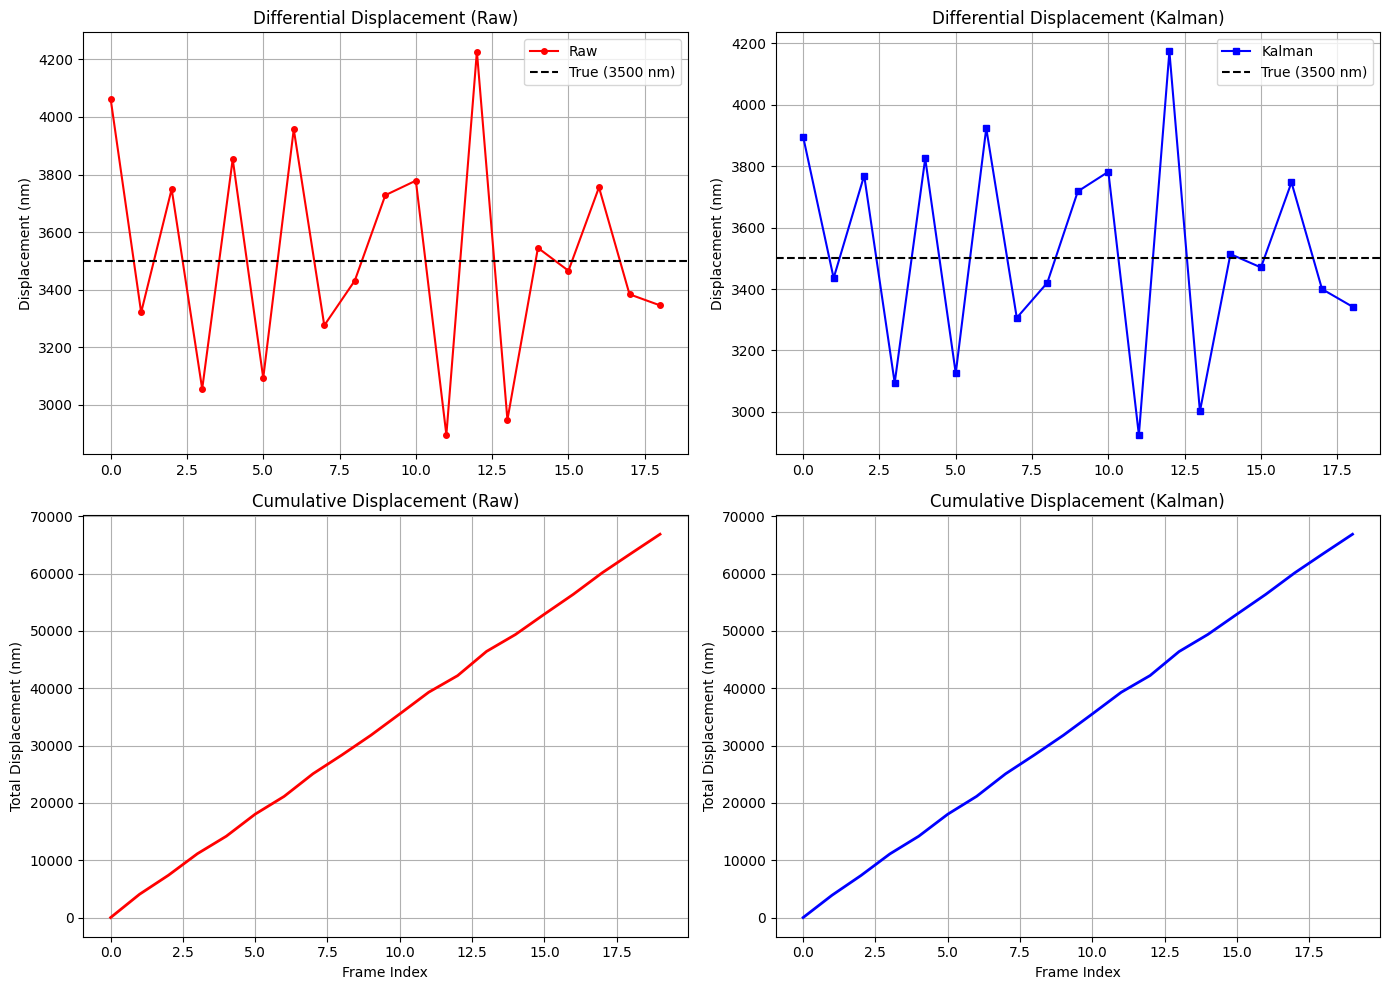

Stats for noise:
  Distortion Type: noise
  Raw Accuracy Std (nm): 369.5789489746094
  Kalman Accuracy Std (nm): 333.91
  Improvement (%): 9.65
  Final Raw Disp (nm): 66868.97
  Final Kalman Disp (nm): 66873.65
  R_est (nm^(2)): 42189.33203125
  Q_est (nm^(2)/frame^(2)): 473300.0625


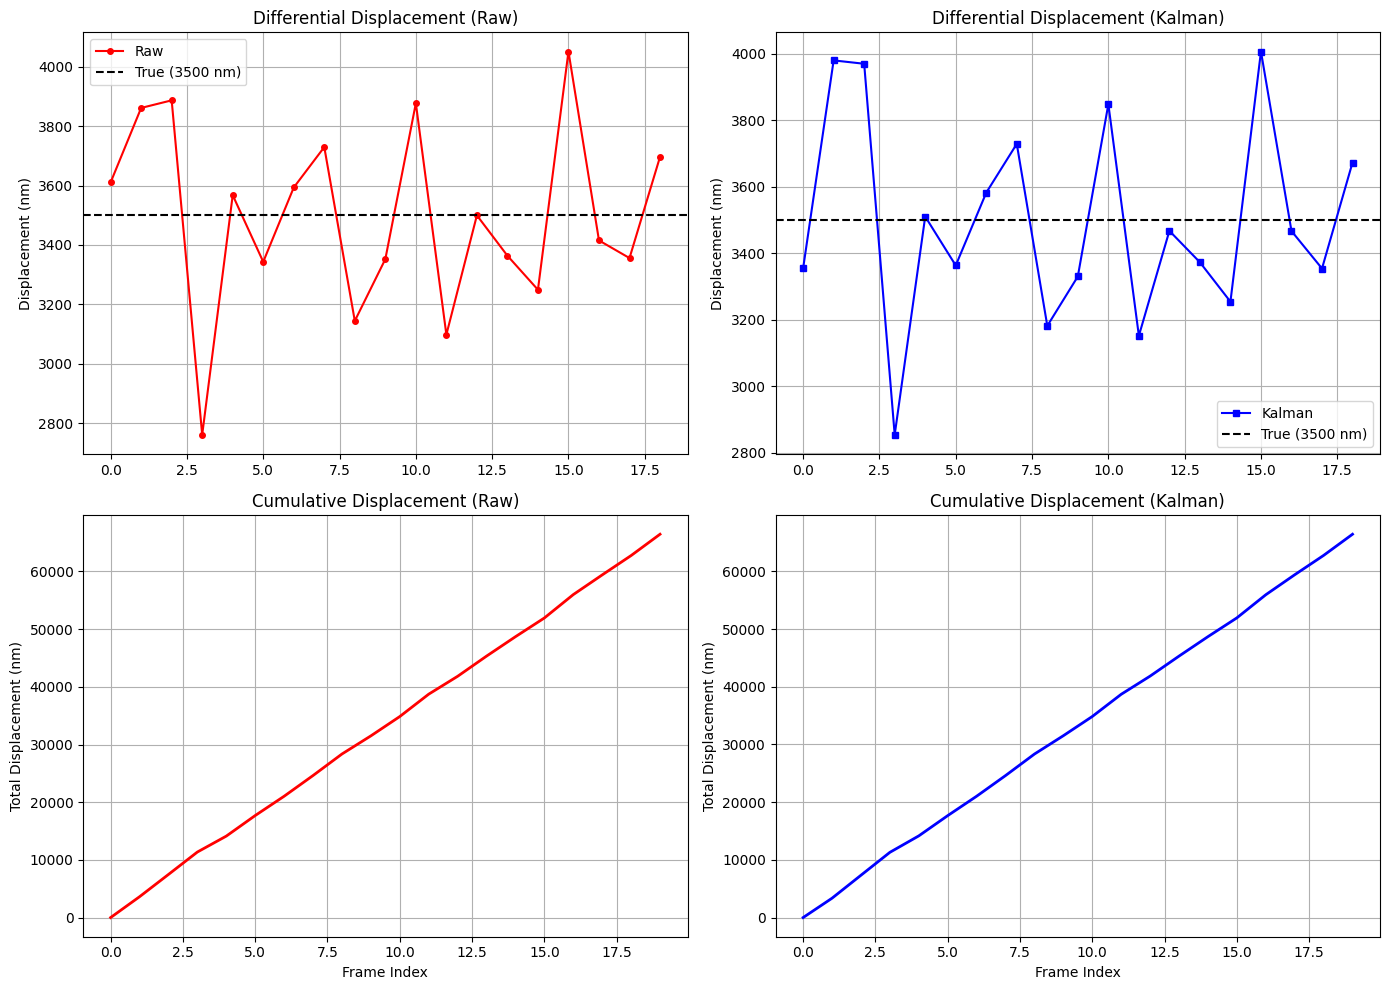

Stats for noise_scratch_blur:
  Distortion Type: noise_scratch_blur
  Raw Accuracy Std (nm): 310.8538513183594
  Kalman Accuracy Std (nm): 301.59
  Improvement (%): 2.98
  Final Raw Disp (nm): 66457.25
  Final Kalman Disp (nm): 66444.84
  R_est (nm^(2)): 43274.21484375
  Q_est (nm^(2)/frame^(2)): 263810.59375


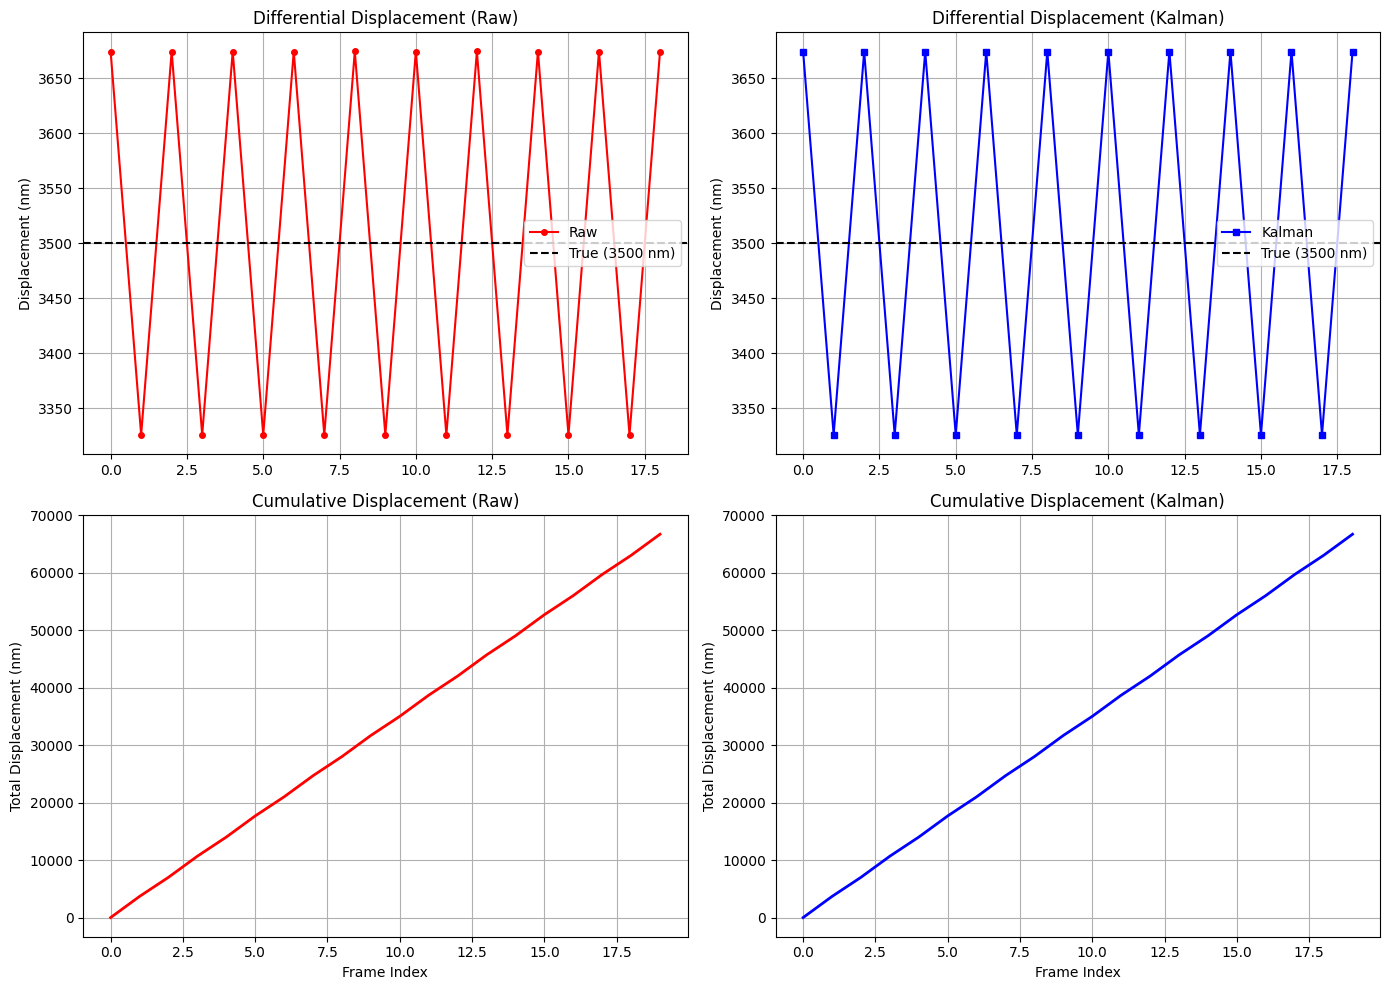

Stats for scratch:
  Distortion Type: scratch
  Raw Accuracy Std (nm): 173.90811157226562
  Kalman Accuracy Std (nm): 173.91
  Improvement (%): 0.00
  Final Raw Disp (nm): 66674.14
  Final Kalman Disp (nm): 66674.14
  R_est (nm^(2)): 1.00
  Q_est (nm^(2)/frame^(2)): 121312.3359375


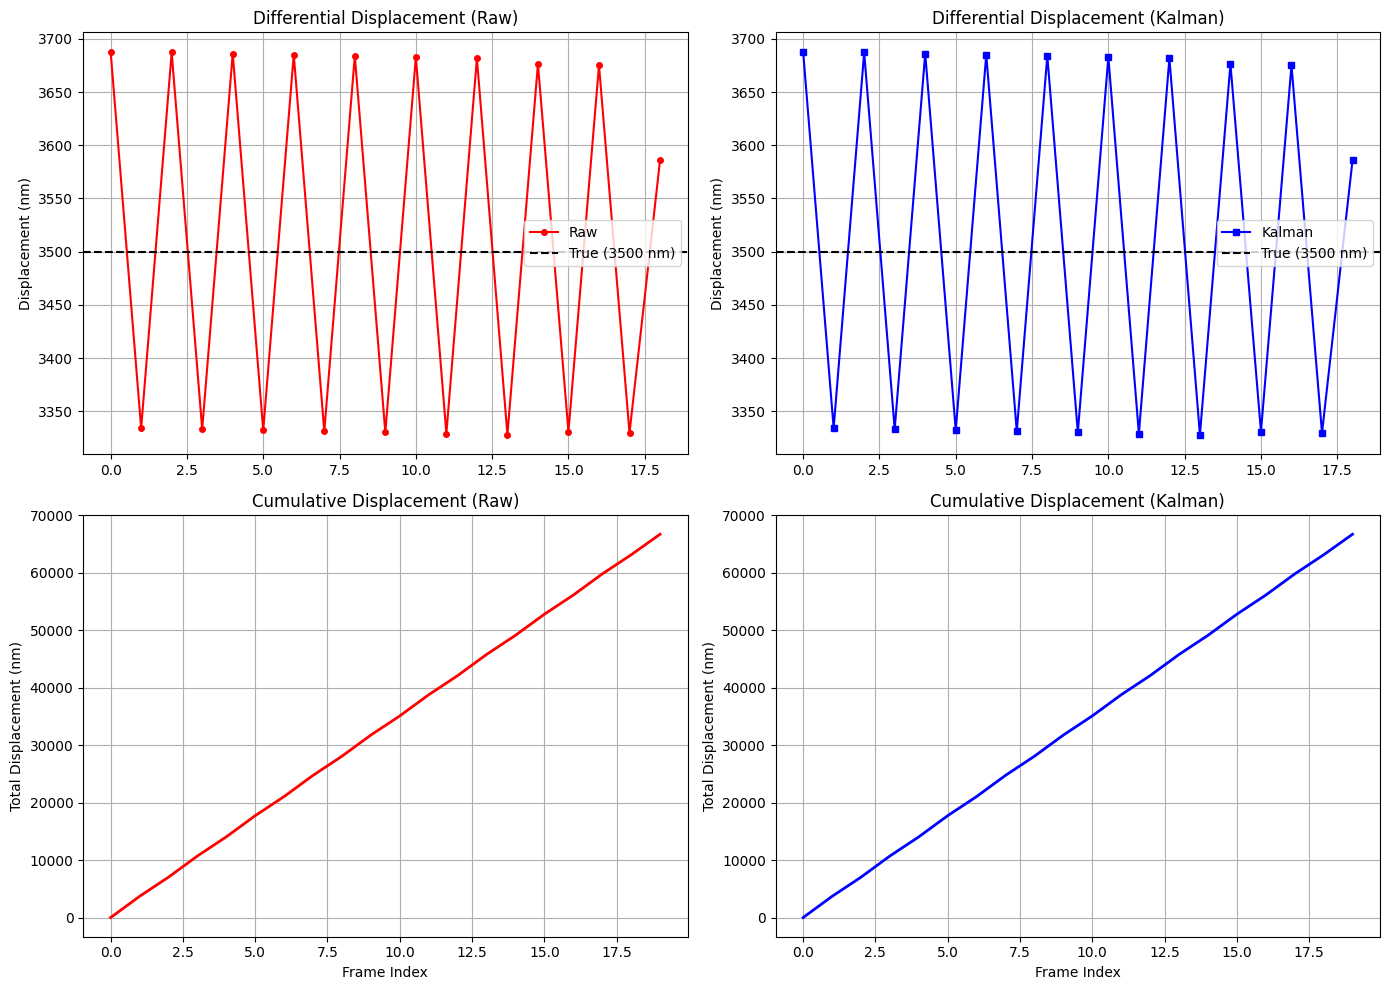

Stats for spot:
  Distortion Type: spot
  Raw Accuracy Std (nm): 172.28541564941406
  Kalman Accuracy Std (nm): 172.28
  Improvement (%): 0.00
  Final Raw Disp (nm): 66711.06
  Final Kalman Disp (nm): 66711.06
  R_est (nm^(2)): 1.00
  Q_est (nm^(2)/frame^(2)): 120457.5859375


In [18]:
def analyze_and_plot(dtype, results):
    raw_diff = results['diff_raw']
    kalman_diff = results['diff_kalman']
    raw_cum = results['cumulative_raw']
    kalman_cum = results['cumulative_kalman']
    
    # Истинное дифференциальное смещение
    true_diff_nm = 0.5 * PIXEL_SIZE_UM * 1000  # 3500 nm
    
    # Ошибки измерения
    raw_errors = raw_diff - true_diff_nm
    kalman_errors = kalman_diff - true_diff_nm
    
    # Точность
    raw_accuracy_std = np.std(raw_errors)
    kalman_accuracy_std = np.std(kalman_errors)
    improvement = (1 - kalman_accuracy_std / raw_accuracy_std) * 100 if raw_accuracy_std > 0 else 0
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Absolute Displacement: before and after
    axes[0,0].plot(raw_diff, 'r-o', label='Raw', markersize=4)
    axes[0,0].axhline(true_diff_nm, color='k', linestyle='--', label='True (3500 nm)')
    axes[0,0].set_title('Differential Displacement (Raw)')
    axes[0,0].set_ylabel('Displacement (nm)')
    axes[0,0].legend()
    axes[0,0].grid(True)
    
    axes[0,1].plot(kalman_diff, 'b-s', label='Kalman', markersize=4)
    axes[0,1].axhline(true_diff_nm, color='k', linestyle='--', label='True (3500 nm)')
    axes[0,1].set_title('Differential Displacement (Kalman)')
    axes[0,1].set_ylabel('Displacement (nm)')
    axes[0,1].legend()
    axes[0,1].grid(True)
    
    # Accumulated displacement: before and after
    axes[1,0].plot(raw_cum, 'r-', linewidth=2)
    axes[1,0].set_title('Cumulative Displacement (Raw)')
    axes[1,0].set_xlabel('Frame Index')
    axes[1,0].set_ylabel('Total Displacement (nm)')
    axes[1,0].grid(True)
    
    axes[1,1].plot(kalman_cum, 'b-', linewidth=2)
    axes[1,1].set_title('Cumulative Displacement (Kalman)')
    axes[1,1].set_xlabel('Frame Index')
    axes[1,1].set_ylabel('Total Displacement (nm)')
    axes[1,1].grid(True)
    
    plt.tight_layout()
    plt.show()
    
    # Statistics
    stats = {
        'Distortion Type': dtype,
        'Raw Accuracy Std (nm)': raw_accuracy_std,
        'Kalman Accuracy Std (nm)': kalman_accuracy_std,
        'Improvement (%)': improvement,
        'Final Raw Disp (nm)': raw_cum[-1],
        'Final Kalman Disp (nm)': kalman_cum[-1],
        'R_est (nm^(2))': results['R_est'],
        'Q_est (nm^(2)/frame^(2))': results['Q_est']
    }
    
    print(f"Stats for {dtype}:")
    for k, v in stats.items():
        if isinstance(v, float):
            print(f"  {k}: {v:.2f}")
        else:
            print(f"  {k}: {v}")
    
    return stats

summary_list = []
for dtype in distortion_types:
    stats = analyze_and_plot(dtype, results_all[dtype])
    summary_list.append(stats)

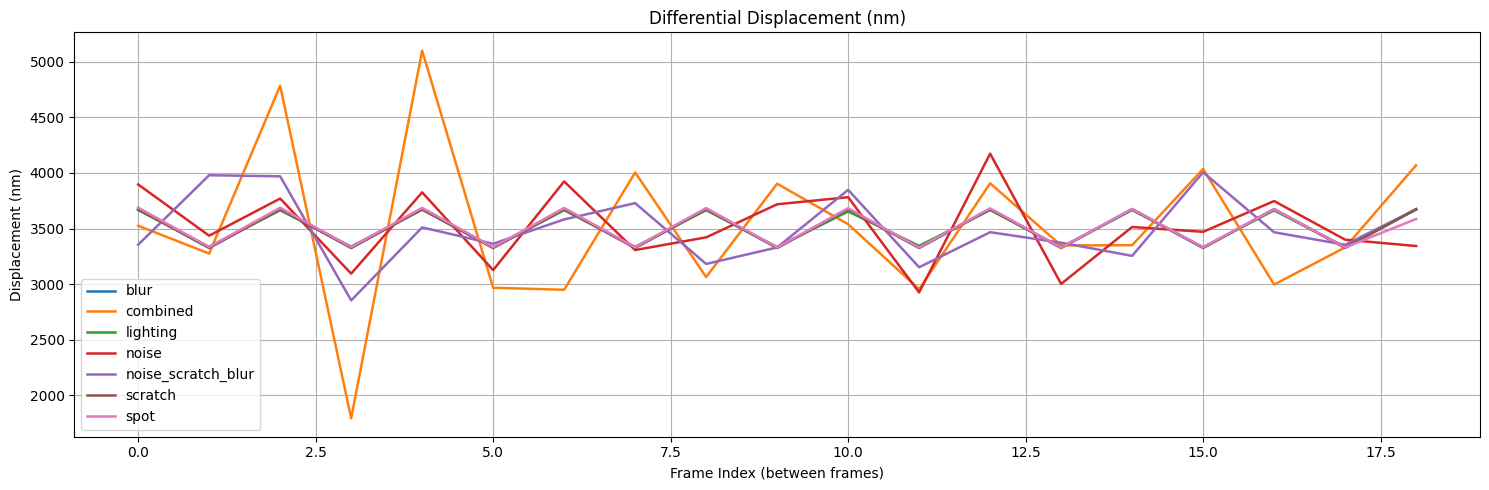

In [19]:
# Optional: Compare methods for all types
plt.figure(figsize=(15, 5))

for dtype in distortion_types:
    data = results_all[dtype]
    diff_shifts = data['diff_kalman']
    plt.plot(diff_shifts, label=dtype, linewidth=1.8)

plt.title('Differential Displacement (nm)')
plt.xlabel('Frame Index (between frames)')
plt.ylabel('Displacement (nm)')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()